In [1]:
import torch
from GEM_module_sparse import Generalized_EM
from utils_sparse import *
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import time
import scipy.sparse as sp
import sksparse.cholmod as cholmod

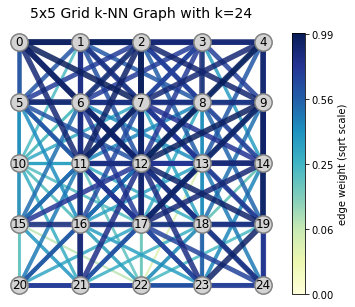

In [2]:
n_row = 5
kernel = 5
k = kernel ** 2 - 1
feature_dim = 3
num_nodes = n_row * n_row
# signal 
features = torch.randn(num_nodes, feature_dim) * 0.4
    # compute weight matrix
    # nearest_neighbors = generate_grid_neigbhors(n_row) #  generate_kNN_from_grid(n_row, kernel, k)
    # edge_weights = features[nearest_neighbors.view(-1)].reshape(num_nodes, 4, feature_dim) - features.unsqueeze(1)  # (N, 4, feature_dim)
    # edge_weights = torch.exp(- (edge_weights ** 2).sum(-1))  # (N, 4)


nearest_neighbors = generate_kNN_from_grid(n_row, kernel, k)
neighbor_mask = nearest_neighbors != -1
edge_weights = features[nearest_neighbors.view(-1)].reshape(num_nodes, k, feature_dim) - features.unsqueeze(1)  # (N, k, feature_dim)
edge_weights = torch.exp(- (edge_weights ** 2).sum(-1))  # (N, k)
edge_weights = edge_weights * neighbor_mask.float()



draw_graph(nearest_neighbors, edge_weights, n_row, title=f"{n_row}x{n_row} Grid k-NN Graph with k={k}")



tensor([[ 5,  1, -1, -1],
        [ 0,  6,  2, -1],
        [ 1,  7,  3, -1],
        [ 2,  8,  4, -1],
        [ 3,  9, -1, -1],
        [ 0, 10,  6, -1],
        [ 5,  1, 11,  7],
        [ 6,  2, 12,  8],
        [ 7,  3, 13,  9],
        [ 8,  4, 14, -1],
        [ 5, 15, 11, -1],
        [10,  6, 16, 12],
        [11,  7, 17, 13],
        [12,  8, 18, 14],
        [13,  9, 19, -1],
        [10, 20, 16, -1],
        [15, 11, 21, 17],
        [16, 12, 22, 18],
        [17, 13, 23, 19],
        [18, 14, 24, -1],
        [15, 21, -1, -1],
        [20, 16, 22, -1],
        [21, 17, 23, -1],
        [22, 18, 24, -1],
        [23, 19, -1, -1]]) tensor([[0.6000, 0.6000, 0.0000, 0.0000],
        [0.6000, 0.6000, 0.6000, 0.0000],
        [0.6000, 0.6000, 0.6000, 0.0000],
        [0.6000, 0.6000, 0.6000, 0.0000],
        [0.6000, 0.6000, 0.0000, 0.0000],
        [0.6000, 0.6000, 0.6000, 0.0000],
        [0.6000, 0.6000, 0.6000, 0.6000],
        [0.6000, 0.6000, 0.6000, 0.6000],
        [0.60

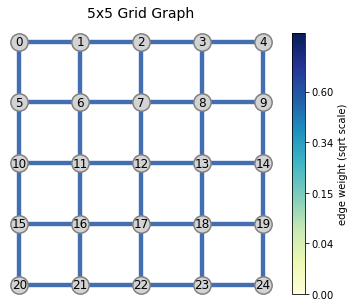

y.shape torch.Size([128, 25])


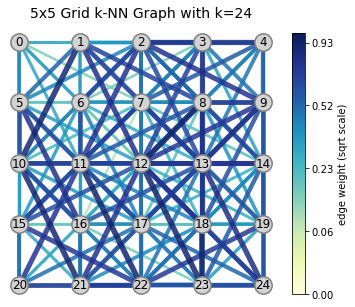

x.shape torch.Size([128, 25])
difference norm: tensor(1.4689, grad_fn=<LinalgVectorNormBackward0>)


In [3]:
# torch.manual_seed(28)  # 固定全局随机种子
gem = Generalized_EM(num_nodes=num_nodes, num_neighbors=k, neighbor_list=nearest_neighbors, mu=0.01, gamma=0.1, step_size=0.1, emb_dim=6, feature_dim=feature_dim, c=8, theta=0.5, method='CG', CG_iters=5, PGD_iters=100, PGD_step_size=0.01, scale=True)

gem.neighbor_mask = neighbor_mask  # set neighbor mask

y = generate_y_from_grid(n_row, sigma=0.1, n=128)
print('y.shape', y.shape)  # (128, num_nodes)


# solve x
x = gem.E_step(y, edge_weights)  # (B, N)
edge_weights = gem.glm(x)  # (N, k)
draw_graph(nearest_neighbors, edge_weights, n_row, title=f"{n_row}x{n_row} Grid k-NN Graph with k={k}")
print('x.shape', x.shape)
print('difference norm:', torch.norm(gem.LHS_E_step(x, edge_weights) - y))


In [4]:
# VALIDATE r-TILDE
r_tilde = gem._r_tilde(edge_weights, CG_method='batch_PCG')  # (B, N)
print((r_tilde * edge_weights).sum())
r_tilde = gem._r_tilde(edge_weights, CG_method='batch_CG')  # (B, N)
print((r_tilde * edge_weights).sum())
gem.method = 'cholmod'
r_tilde = gem._r_tilde(edge_weights)  # (B, N)
print((r_tilde * edge_weights).sum())
gem.method = 'Hutchinson'
r_tilde = gem._r_tilde(edge_weights, CG_method='batch_PCG')  # (B, N)
print((r_tilde * edge_weights).sum())

tensor(47.9504, grad_fn=<SumBackward0>)
tensor(47.9555, grad_fn=<SumBackward0>)
tensor(47.9536, grad_fn=<SumBackward0>)
tensor(48.3271, grad_fn=<SumBackward0>)


In [5]:
glr = gem.GLR(x, edge_weights, method='Lx')
glr_1 = gem.GLR(x, edge_weights, method='edge_diff')
print(glr, glr_1)
print('GLR difference norm:', torch.norm(glr - glr_1))  # should be close to 0

tensor(99.3389, grad_fn=<DivBackward0>) tensor(99.3389, grad_fn=<MulBackward0>)
GLR difference norm: tensor(7.6294e-06, grad_fn=<LinalgVectorNormBackward0>)


In [6]:
new_params_proxy = gem.M_step_1(x, edge_weights)
# gem.user_proxy_loss = False
new_params_slq = gem.M_step_1(x, edge_weights, use_proxy_loss=False)

# compare parameter updates
for name in new_params_proxy:
    print(f"Parameter: {name}")
    # print("Update with proxy loss:")
    # print(new_params_proxy[name])
    # print("Update with SLQ:")
    # print(new_params_slq[name])
    print("Difference norm:", torch.norm(new_params_proxy[name] - new_params_slq[name]))

tr(RL)= 23.98084259033203
use proxy loss
slq logdet
40.78659725189209
logdet(L+J or L+eI)= 40.78659725189209
Parameter: node_embeddings
Difference norm: tensor(0.3863, grad_fn=<LinalgVectorNormBackward0>)
Parameter: theta
Difference norm: tensor(3.2719, grad_fn=<LinalgVectorNormBackward0>)
Parameter: fc.weight
Difference norm: tensor(3.8339, grad_fn=<LinalgVectorNormBackward0>)
Parameter: fc.bias
Difference norm: tensor(1.3489, grad_fn=<LinalgVectorNormBackward0>)
